/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Test Results:
I am very happy → 😊
I hate this → 😡
this is bad → 😢


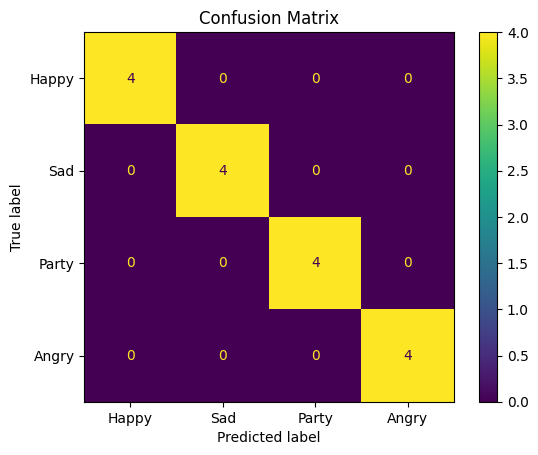

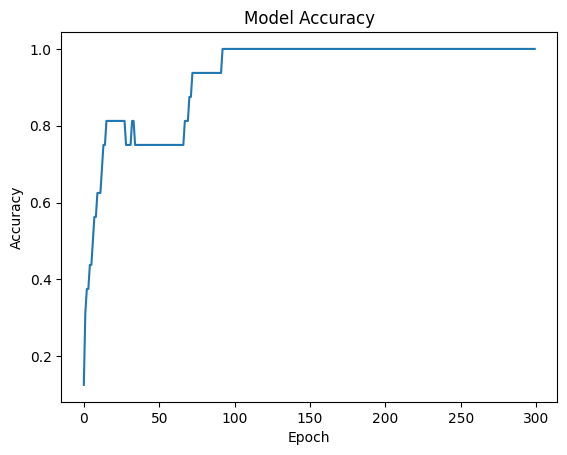

In [ ]:
#------------------Libraries-------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ---------------- DATA ----------------
texts = [
    "I love you", "I am happy", "feeling great", "this is amazing",
    "I am sad", "feeling down", "this is bad", "I am depressed",
    "let's party", "so excited", "celebration time", "fun night",
    "I am angry", "I hate this", "so annoying", "this is frustrating"
]

labels = np.array([
    0,0,0,0,
    1,1,1,1,
    2,2,2,2,
    3,3,3,3
])

emoji_dict = {0:"😊",1:"😢",2:"🎉",3:"😡"}

# ---------------- TOKENIZATION ----------------
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
seqs = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(seqs, maxlen=5)

# ---------------- MODEL ----------------
model = Sequential([
    Embedding(input_dim=500, output_dim=16, input_length=5),
    LSTM(32),
    Dense(4, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# ---------------- TRAIN ----------------
history = model.fit(padded, labels, epochs=300, verbose=0)

# ---------------- PREDICTION ----------------
def predict(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=5)
    pred = np.argmax(model.predict(pad, verbose=0))
    return emoji_dict[pred]

print("Test Results:")
print("I am very happy →", predict("I am very happy"))
print("I hate this →", predict("I hate this"))
print("this is bad →", predict("this is bad"))

# ---------------- EVALUATION ----------------
preds = np.argmax(model.predict(padded, verbose=0), axis=1)

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Happy","Sad","Party","Angry"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# ---------------- ACCURACY GRAPH ----------------
plt.plot(history.history['accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()